In [91]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [92]:
df=pd.read_csv("phase1_dataset.csv")

# Eda 

In [93]:
df.shape

(1429445, 80)

In [94]:
df.isnull().sum().sort_values(ascending=False)

Flow Bytes/s               125
Unnamed: 0                   0
 Flow Duration               0
 Destination Port            0
 Total Backward Packets      0
                          ... 
Idle Mean                    0
 Idle Std                    0
 Idle Max                    0
 Idle Min                    0
 Label                       0
Length: 80, dtype: int64

In [95]:
#droping the null values because they are very less in numbe
df.dropna(inplace=True)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1429320 entries, 0 to 1429444
Data columns (total 80 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   Unnamed: 0                    1429320 non-null  int64  
 1    Destination Port             1429320 non-null  int64  
 2    Flow Duration                1429320 non-null  int64  
 3    Total Fwd Packets            1429320 non-null  int64  
 4    Total Backward Packets       1429320 non-null  int64  
 5   Total Length of Fwd Packets   1429320 non-null  int64  
 6    Total Length of Bwd Packets  1429320 non-null  int64  
 7    Fwd Packet Length Max        1429320 non-null  int64  
 8    Fwd Packet Length Min        1429320 non-null  int64  
 9    Fwd Packet Length Mean       1429320 non-null  float64
 10   Fwd Packet Length Std        1429320 non-null  float64
 11  Bwd Packet Length Max         1429320 non-null  int64  
 12   Bwd Packet Length Min        142

In [97]:
df.isin([np.inf, -np.inf]).sum().sort_values(ascending=False)
# here there are infinite values also so we need to brought them into range using quantiles


Flow Bytes/s               988
 Flow Packets/s            988
 Flow Duration               0
Unnamed: 0                   0
 Total Backward Packets      0
                          ... 
Idle Mean                    0
 Idle Std                    0
 Idle Max                    0
 Idle Min                    0
 Label                       0
Length: 80, dtype: int64

In [98]:
# removing infinite values 
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [99]:
df.columns
df.drop(columns=["Unnamed: 0"], inplace=True)

In [100]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal


In [101]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,...,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06
mean,9.022252e+03,1.025006e+07,8.054142e+00,8.782038e+00,5.616576e+02,1.284124e+04,2.144722e+02,1.944947e+01,6.237530e+01,7.238585e+01,...,5.500048e+00,-1.324884e+03,8.158411e+04,3.574252e+04,1.453838e+05,6.146526e+04,4.114830e+06,6.989057e+05,4.616633e+06,3.584996e+06
std,1.898654e+04,2.826184e+07,6.766183e+02,8.979146e+02,1.273040e+04,2.032902e+06,8.566053e+02,7.233282e+01,2.256903e+02,3.481167e+02,...,6.450196e+02,3.366139e+05,6.475234e+05,3.675547e+05,1.001190e+06,5.810356e+05,1.422964e+07,5.512580e+06,1.595245e+07,1.346435e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,8.600000e+01,1.000000e+00,1.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.069200e+04,2.000000e+00,2.000000e+00,5.000000e+01,1.020000e+02,3.200000e+01,6.000000e+00,2.900000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.049000e+03,9.139490e+05,4.000000e+00,3.000000e+00,9.600000e+01,3.420000e+02,5.100000e+01,3.500000e+01,4.700000e+01,1.026320e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.260000e+02,1.100000e+08,7.050000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.660000e+07,1.200000e+08,1.200000e+08


# making the data perfect 

In [102]:
df.shape

(1428332, 79)

In [103]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,...,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06
mean,9.022252e+03,1.025006e+07,8.054142e+00,8.782038e+00,5.616576e+02,1.284124e+04,2.144722e+02,1.944947e+01,6.237530e+01,7.238585e+01,...,5.500048e+00,-1.324884e+03,8.158411e+04,3.574252e+04,1.453838e+05,6.146526e+04,4.114830e+06,6.989057e+05,4.616633e+06,3.584996e+06
std,1.898654e+04,2.826184e+07,6.766183e+02,8.979146e+02,1.273040e+04,2.032902e+06,8.566053e+02,7.233282e+01,2.256903e+02,3.481167e+02,...,6.450196e+02,3.366139e+05,6.475234e+05,3.675547e+05,1.001190e+06,5.810356e+05,1.422964e+07,5.512580e+06,1.595245e+07,1.346435e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,8.600000e+01,1.000000e+00,1.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.069200e+04,2.000000e+00,2.000000e+00,5.000000e+01,1.020000e+02,3.200000e+01,6.000000e+00,2.900000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.049000e+03,9.139490e+05,4.000000e+00,3.000000e+00,9.600000e+01,3.420000e+02,5.100000e+01,3.500000e+01,4.700000e+01,1.026320e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.260000e+02,1.100000e+08,7.050000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.660000e+07,1.200000e+08,1.200000e+08


In [104]:
def clean_data(df):
    # Drop column: ' Bwd PSH Flags'
    df = df.drop(columns=[' Bwd PSH Flags'])
    # Drop column: ' Bwd URG Flags'
    df = df.drop(columns=[' Bwd URG Flags'])
    # Drop column: 'Fwd Avg Bytes/Bulk'
    df = df.drop(columns=['Fwd Avg Bytes/Bulk'])
    # Drop column: ' Fwd Avg Packets/Bulk'
    df = df.drop(columns=[' Fwd Avg Packets/Bulk'])
    # Drop column: ' Fwd Avg Bulk Rate'
    df = df.drop(columns=[' Fwd Avg Bulk Rate'])
    # Drop columns: ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'
    df = df.drop(columns=[' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'])
    return df

# Loaded variable 'df' from kernel stat

df = clean_data(df.copy())

In [105]:
df.columns=df.columns.str.strip()  

Label
Normal    79.779491
Attack    20.220509
Name: proportion, dtype: float64


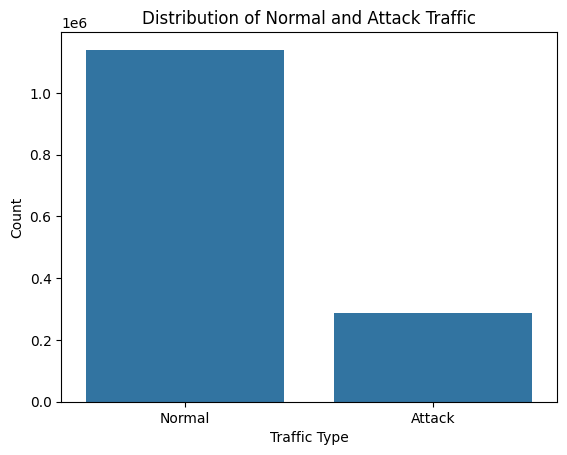

In [106]:
print(df["Label"].value_counts(normalize=True)*100)
sns.countplot(x='Label', data=df)   # here data is imbalance 20% are attack and 80% are normal
plt.title('Distribution of Normal and Attack Traffic')
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.show()

In [107]:
df.shape

(1428332, 71)

In [108]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',

# Understanding Each fearures 


---

# 🔥 Big Picture Pehle Samjho

Ye 70 features 5 major categories me aate hain:

1. **Flow Basics (connection level info)**
2. **Packet Size & Count**
3. **Timing (IAT – Inter Arrival Time)**
4. **TCP Flags (behavior signals)**
5. **Activity/Idle patterns (session behavior)**

Agar tum in categories samajh gaye → pura dataset samajh gaye.

---

# 🧠 1. Flow Basics (Connection Level)

### 👉 Destination Port

* Kis service pe traffic ja raha hai (80 = HTTP, 443 = HTTPS)
* Attackers often unusual ports target karte hain

### 👉 Flow Duration

* Ek connection kitni der chala
* DDoS → short burst flows
* Slow attacks → long duration

---

# 📦 2. Packet Count & Volume Features

### 👉 Total Fwd Packets / Total Backward Packets

* Forward = client → server
* Backward = server → client

👉 Example:

* Normal browsing → balanced
* DDoS → mostly forward heavy

---

### 👉 Total Length of Fwd/Bwd Packets

* Total data transferred

👉 Example:

* Large downloads → high backward bytes
* Attack → abnormal ratios

---

### 👉 Packet Length (Max, Min, Mean, Std)

* Packet sizes ka distribution

👉 Example:

* Bot traffic → uniform packets
* Normal traffic → varied sizes

---

# ⚡ 3. Flow Speed Features

### 👉 Flow Bytes/s

* Data transfer speed

### 👉 Flow Packets/s

* Packet rate

👉 Example:

* DDoS → extremely high packets/sec
* Normal → moderate

---

# ⏱️ 4. Timing Features (MOST IMPORTANT)

### 👉 IAT = Inter Arrival Time

#### Flow IAT Mean/Std/Max/Min

* Packets ke beech ka gap

👉 Example:

* Normal traffic → irregular gaps
* Attack scripts → very consistent timing

---

### 👉 Fwd IAT & Bwd IAT

* Direction-wise timing

👉 Example:

* Bot → predictable pattern
* Human → random pattern

---

# 🚨 5. TCP Flags (VERY POWERFUL)

### 👉 SYN Flag Count

* Connection start signal

👉 SYN flood attack → high SYN count

---

### 👉 ACK Flag Count

* Normal communication indicator

---

### 👉 RST Flag Count

* Connection reset

👉 Attack → abnormal resets

---

### 👉 PSH, URG Flags

* Data urgency indicators

👉 Rare in normal traffic → suspicious when high

---

# ⚖️ 6. Ratios & Derived Features

### 👉 Down/Up Ratio

* Server response vs request

👉 Example:

* Download → high down
* Attack → weird imbalance

---

### 👉 Average Packet Size

* Overall behavior indicator

---

# 🔁 7. Subflow Features

### 👉 Subflow Fwd/Bwd Packets & Bytes

* Flow ke internal segments

👉 Useful for detecting fragmented attacks

---

# 🔐 8. Window Size Features

### 👉 Init_Win_bytes_forward/backward

* TCP window size

👉 Attack tools often use abnormal values

---

# 📊 9. Activity vs Idle (VERY IMPORTANT)

### 👉 Active Mean/Std/Max/Min

* Jab connection active hai

### 👉 Idle Mean/Std/Max/Min

* Jab gap hai

👉 Example:

* Human browsing → active + idle mix
* Bot attack → continuous active

---

# 🔥 Hidden Insight (Important)

Agar tum dhyan se dekho:

* Packet size + timing + flags
  → milke behavior define karte hain

Single feature se attack detect nahi hota
Combination se hota hai

---

# 💣 Brutal Truth

Agar tum:

* Sirf feature names yaad kar rahe ho → useless
* Behavior samajh rahe ho → powerful

Examiner ko impress karna hai toh bolo:

👉 “Features capture statistical, temporal, and protocol-level behavior of network flows”

---

# 🎯 Simple Mental Model

Socho:

| Behavior Type     | Feature Group      |
| ----------------- | ------------------ |
| Kitna data        | Length features    |
| Kitne packets     | Count features     |
| Kitni speed       | Bytes/s, Packets/s |
| Kitna gap         | IAT                |
| Kaise connect hua | Flags              |
| Human vs bot      | Active/Idle        |

---

# 🚀 Final Advice

EDA me tumhe ye dikhana chahiye:

* Attack vs benign ka difference in:

  * Packets/s
  * IAT
  * Flags
  * Packet size


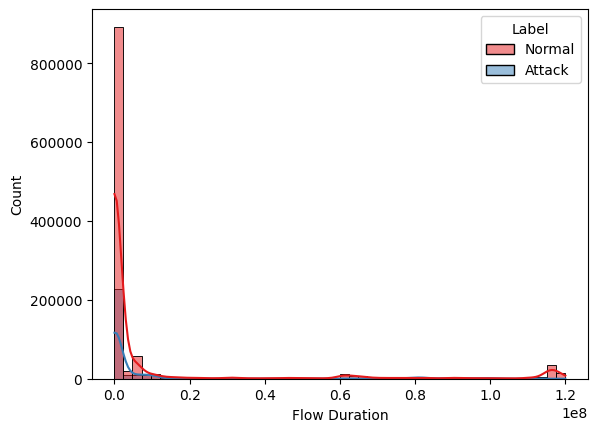

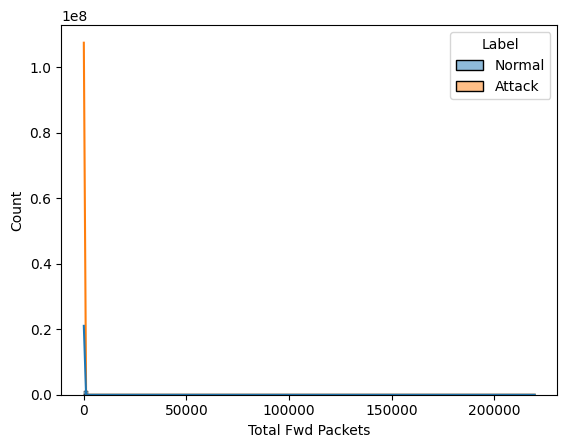

In [109]:
sns.histplot(x=df["Flow Duration"], bins=50, kde=True,hue= df["Label"], palette="Set1")
plt.show()# these are the in microseconds
sns.histplot(x=df["Total Fwd Packets"],bins=100,kde=True,hue=df["Label"])# here there are very much outliers in the data so we need to remove them using quantiles
plt.show()


# removing the Outliers and second option jayada value hai toh kya Flow duration in mili seconds 

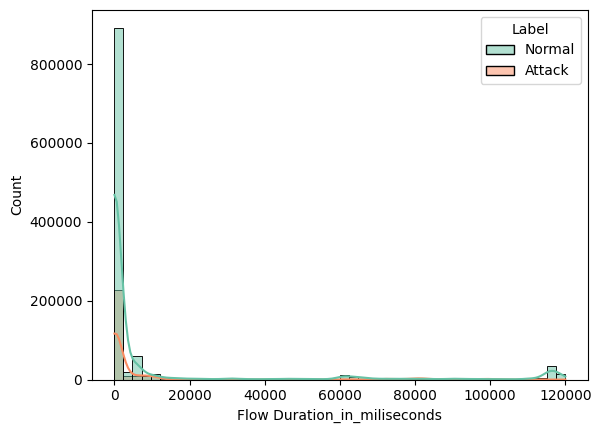

In [110]:
df["Flow Duration_in_miliseconds"]=df["Flow Duration"]/1000
sns.histplot(x=df["Flow Duration_in_miliseconds"], bins=50, kde=True,hue= df["Label"], palette="Set2")
plt.show()# these are the in milliseconds now we can see the distribution of flow duration more

In [111]:
df["Label"]=df["Label"].map({"Normal": 0, "Attack": 1})

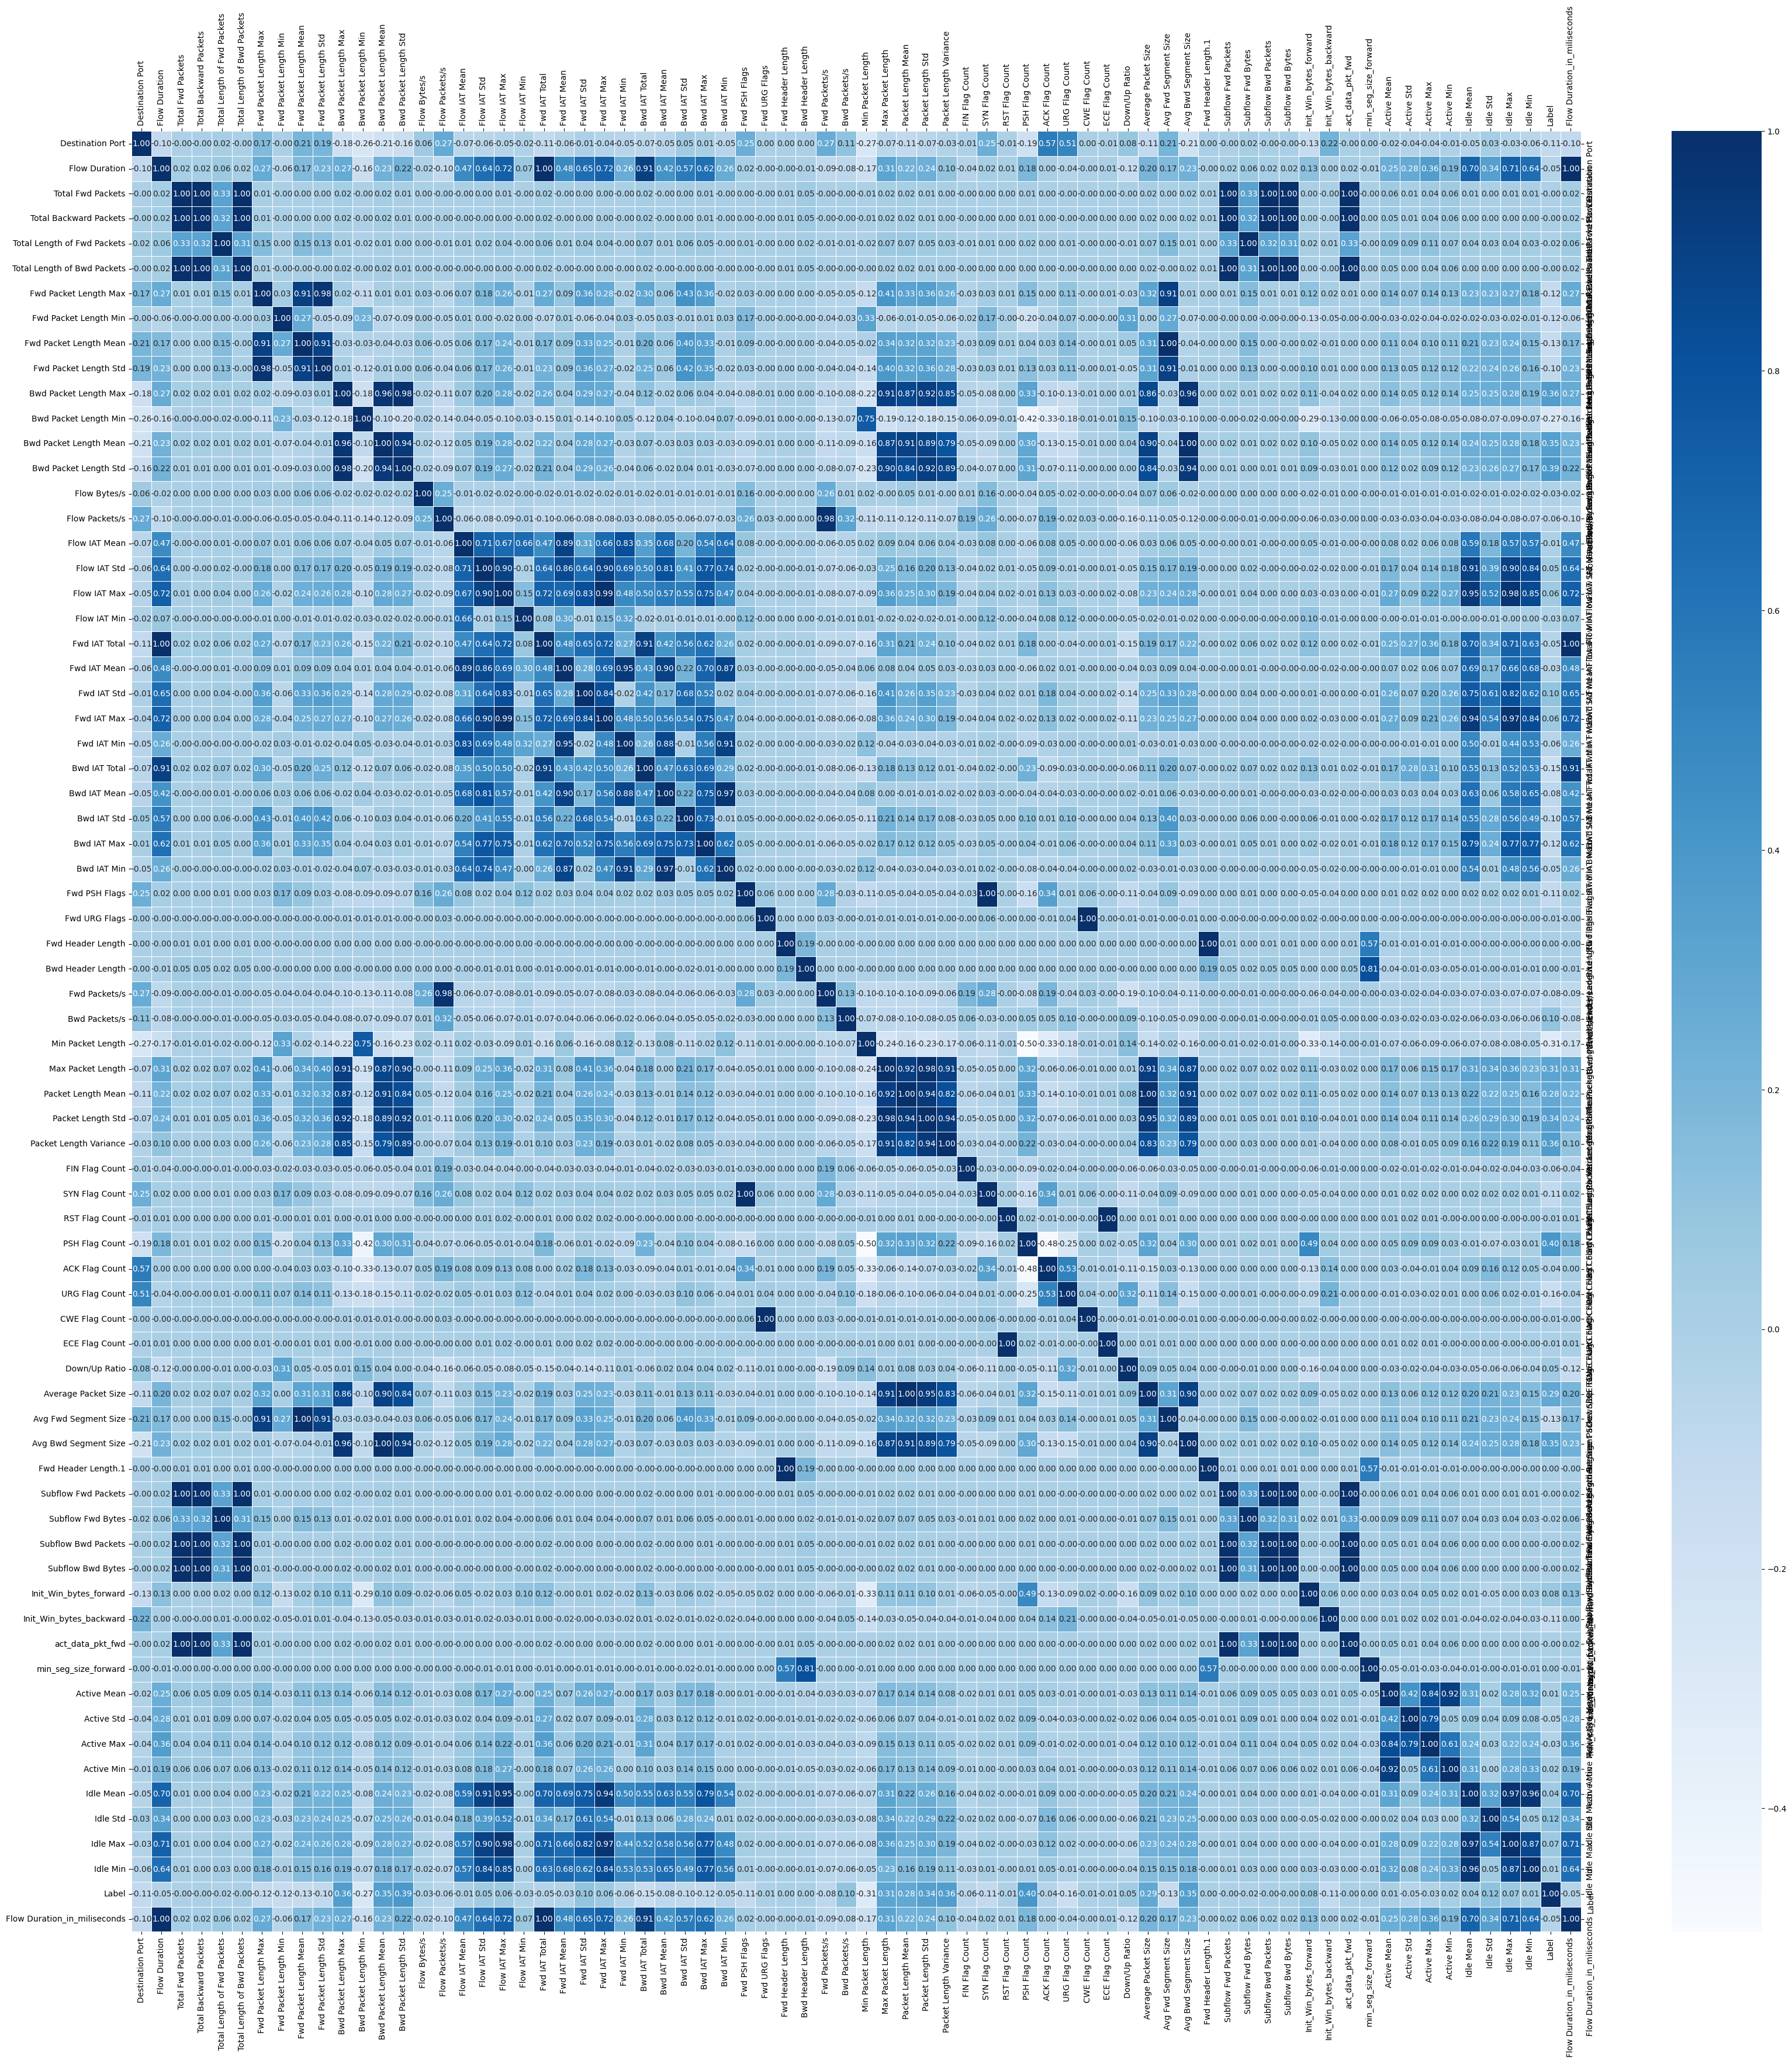

'\nWhich Features should be selected or not showing multicollinearity\nvia reading the blocks we can choose general and practical features for the model building\nHere we examine so me features \nuse mean over MAX and MIN because they are more robust to outliers\nhere we need to engineer some features also so i prefer some features which are \n\n1.Total_lenght_of_Fwd_Packets/Total_lenght_of_Bwd_Packets\n2.Subflow fwd bytes/ Subflow bwd bytes\n\n\n'

In [112]:

# Create the figure
plt.figure(figsize=(40, 40))

# Generate the heatmap and capture the 'ax' object
ax = sns.heatmap(df.corr(numeric_only=True), cmap='Blues', annot=True, fmt=".2f", linewidths=.5)

# Force labels to appear on all sides
ax.tick_params(
    top=True, labeltop=True,       # Enable top labels
    bottom=True, labelbottom=True, # Ensure bottom labels stay on
    left=True, labelleft=True,     # Ensure left labels stay on
    right=True, labelright=True    # Enable right labels
)

# Optional: Rotate top labels if they overlap at size 40x40
plt.setp(ax.get_xticklabels(), rotation=90)

plt.show()

'''
Which Features should be selected or not showing multicollinearity
via reading the blocks we can choose general and practical features for the model building
Here we examine so me features 
use mean over MAX and MIN because they are more robust to outliers
here we need to engineer some features also so i prefer some features which are 

1.Total_lenght_of_Fwd_Packets/Total_lenght_of_Bwd_Packets
2.Subflow fwd bytes/ Subflow bwd bytes


'''



In [113]:
features_todrop = [
    "Flow IAT Max", "Flow IAT Min", "Fwd IAT Max", "Fwd IAT Min", 
    "Bwd IAT Max", "Bwd IAT Min", "Flow Duration_in_miliseconds", 
    "Min Packet Length", "Max Packet Length", "Packet Length Variance", 
    "Active Max", "Active Min", "Idle Max", "Idle Min", 
    "Fwd Packet Length Max", "Fwd Packet Length Min"
]

In [114]:
df.drop(columns=features_todrop, inplace=True, errors='ignore')

In [115]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Mean', 'Packet Length Std', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
       'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
       'Fwd Header Length.1', 'Subflow Fwd Packets', 'Su

In [116]:
df.drop(columns=["Bwd Packet Length Max","Average Packet Size"],inplace=True, errors='ignore')

In [117]:
correlation=df.corr()["Label"].abs().sort_values(ascending=False)*100

In [118]:
correlation

Label                          100.000000
PSH Flag Count                  40.209525
Bwd Packet Length Std           39.081681
Bwd Packet Length Mean          35.213360
Avg Bwd Segment Size            35.213360
Packet Length Std               33.724246
Packet Length Mean              28.460771
Bwd Packet Length Min           26.772891
URG Flag Count                  16.376688
Bwd IAT Total                   14.934488
Fwd Packet Length Mean          12.878953
Avg Fwd Segment Size            12.878953
Idle Std                        11.769110
Destination Port                10.935387
Fwd PSH Flags                   10.886363
SYN Flag Count                  10.886363
Init_Win_bytes_backward         10.692486
Bwd Packets/s                   10.420937
Fwd IAT Std                     10.239257
Bwd IAT Std                     10.023585
Fwd Packet Length Std            9.974891
Fwd Packets/s                    8.392575
Bwd IAT Mean                     8.096683
Init_Win_bytes_forward           7

In [119]:
worst_features=correlation[correlation<=1].index
len(worst_features)

17

In [120]:
worst_features

Index(['Flow IAT Mean', 'CWE Flag Count', 'Fwd URG Flags', 'ECE Flag Count',
       'RST Flag Count', 'Active Mean', 'Subflow Fwd Packets',
       'Total Fwd Packets', 'Total Backward Packets', 'Subflow Bwd Packets',
       'act_data_pkt_fwd', 'Subflow Bwd Bytes', 'Total Length of Bwd Packets',
       'min_seg_size_forward', 'Bwd Header Length', 'Fwd Header Length',
       'Fwd Header Length.1'],
      dtype='object')

In [121]:
df.drop(columns=worst_features, inplace=True)

In [122]:
df.head()

,Destination Port,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,...,Down/Up Ratio,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,Active Std,Idle Mean,Idle Std,Label
0,54865,3,12,6.0,0.0,0,0.0,0.0,4.000000e+06,666666.66670,...,0,6.0,0.0,12,33,-1,0.0,0.0,0.0,0
1,55054,109,6,6.0,0.0,6,6.0,0.0,1.100917e+05,18348.62385,...,1,6.0,6.0,6,29,256,0.0,0.0,0.0,0
2,55055,52,6,6.0,0.0,6,6.0,0.0,2.307692e+05,38461.53846,...,1,6.0,6.0,6,29,256,0.0,0.0,0.0,0
3,46236,34,6,6.0,0.0,6,6.0,0.0,3.529412e+05,58823.52941,...,1,6.0,6.0,6,31,329,0.0,0.0,0.0,0
4,54863,3,12,6.0,0.0,0,0.0,0.0,4.000000e+06,666666.66670,...,0,6.0,0.0,12,32,-1,0.0,0.0,0.0,0


In [123]:
df.drop(columns="Bwd Packet Length Min",inplace=True)

In [124]:
df.describe()# this is the final data 

,Destination Port,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Std,...,Down/Up Ratio,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,Active Std,Idle Mean,Idle Std,Label
count,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,...,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06
mean,9.022252e+03,1.025006e+07,5.616576e+02,6.237530e+01,7.238585e+01,2.574797e+02,2.841198e+02,1.375240e+06,6.171359e+04,1.747517e+06,...,7.456369e-01,6.237530e+01,2.574797e+02,5.616368e+02,7.861642e+03,1.942556e+03,3.574252e+04,4.114830e+06,6.989057e+05,2.022051e-01
std,1.898654e+04,2.826184e+07,1.273040e+04,2.256903e+02,3.481167e+02,5.762427e+02,8.357112e+02,2.437934e+07,2.233253e+05,5.959124e+06,...,7.784611e-01,2.256903e+02,5.762427e+02,1.270937e+04,1.513729e+04,8.349285e+03,3.675547e+05,1.422964e+07,5.512580e+06,4.016445e-01
min,0.000000e+00,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.930000e+08,-2.000000e+06,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,8.600000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,2.058030e+02,9.389460e+00,0.000000e+00,...,0.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.069200e+04,5.000000e+01,2.900000e+01,0.000000e+00,5.628571e+01,0.000000e+00,8.759543e+03,1.294959e+02,1.024809e+02,...,1.000000e+00,2.900000e+01,5.628571e+01,5.000000e+01,2.560000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.049000e+03,9.139490e+05,9.600000e+01,4.700000e+01,1.026320e+01,1.550000e+02,3.464102e+00,2.000000e+05,2.739726e+04,2.008214e+05,...,1.000000e+00,4.700000e+01,1.550000e+02,9.600000e+01,8.192000e+03,2.290000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,1.290000e+07,5.940857e+03,7.125597e+03,5.800500e+03,8.194660e+03,2.071000e+09,4.000000e+06,8.480026e+07,...,1.560000e+02,5.940857e+03,5.800500e+03,1.287034e+07,6.553500e+04,6.553500e+04,7.050000e+07,1.200000e+08,7.660000e+07,1.000000e+00


# removing Outliers 

In [125]:
normal_data=df[df["Label"]==0]
attack_data=df[df["Label"]==1]

In [128]:
normal_data.columns

Index(['Destination Port', 'Flow Duration', 'Total Length of Fwd Packets',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Fwd PSH Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Mean',
       'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
       'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Active Std',
       'Idle Mean', 'Idle Std', 'Label'],
      dtype='object')

In [129]:
def cap_outliers(df, columns):
    for col in columns:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        
        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])
        
    return df
cap_cols = [
    "Flow Duration",
    "Flow Bytes/s",
    "Flow Packets/s",

    "Flow IAT Std",
    "Fwd IAT Total", "Fwd IAT Mean", "Fwd IAT Std",
    "Bwd IAT Total", "Bwd IAT Mean", "Bwd IAT Std",

    "Packet Length Mean", "Packet Length Std",
    "Fwd Packet Length Mean", "Fwd Packet Length Std",
    "Bwd Packet Length Mean", "Bwd Packet Length Std",

    "Fwd Packets/s",
    "Bwd Packets/s",

    "Active Std",
    "Idle Mean",
    "Idle Std"
]

In [130]:
numerical_features_normal=cap_outliers(normal_data, columns=cap_cols)

In [131]:
df_clean_phase1=pd.concat([numerical_features_normal, attack_data], ignore_index=True)

In [133]:
df_clean_phase1.shape

(1428332, 36)

# Training a baseline model to see the performance 
# logistic regression 

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(df_clean_phase1.drop(columns=["Label"]), df_clean_phase1["Label"], test_size=0.2, random_state=42,stratify=df_clean_phase1["Label"])

In [136]:
lg=LogisticRegression(max_iter=1000)
lg.fit(xtrain, ytrain)
ypred=lg.predict(xtest)

In [137]:
print(classification_report(ytest, ypred))
print("---"*30)
print(confusion_matrix(ytest, ypred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95    227904
           1       0.80      0.75      0.78     57763

    accuracy                           0.91    285667
   macro avg       0.87      0.85      0.86    285667
weighted avg       0.91      0.91      0.91    285667

------------------------------------------------------------------------------------------
[[217305  10599]
 [ 14205  43558]]
